Here we compresss all SNIa points into 36 points in redshift $\{z_n\}_{n=1}^{36}$ through emcee. 
$$
    \bar{m}_B(z) = (1-\alpha)m^{\text{CP}}_{B}(z_{n})+\alpha m^{\text{CP}}_{B}(z_{n+1}),\  \text{where}\  \alpha=\frac{\ln (z/z_n)}{\ln(z_{n+1}/z_n)}
$$
z_match 匹配的红移=z_bao
z_grid 用来画连续的重构图的红移
z_sn SNIa数据里面的红移
z_bao bao数据里面的红移 分为z_bao_dv和z_bao_dm两种
z_cp 控制点的红移

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import os

from utils import *
import utils

np.random.seed(42)
os.makedirs('fig', exist_ok=True)

n_cp = 48
n_walkers = 96 
n_mcmc_steps = 70000

c = 299792.458
z_bao_dv, DV_rd, DV_rd_err = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
z_bao_dm, DM_rd, DM_rd_err = np.loadtxt('data/Combine_DM_rd.dat', unpack=True)
_, H_dv, H_dv_err = np.loadtxt('output/Hz_DVreconstruct_results.txt', unpack=True)
z_bao = np.concatenate((z_bao_dv, z_bao_dm)) 

sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values

with open('data/Pantheon+SH0ES_STAT+SYS.cov', 'r') as f:
    lines = f.readlines()
N_cov = int(lines[0].strip())
cov_vec = np.array([float(x.strip()) for x in lines[1:]])
cov_full = cov_vec.reshape((N_cov, N_cov))
cov_inv = np.linalg.inv(cov_full)
mB_obs_std = np.sqrt(np.diag(cov_full))

cc_cov = np.loadtxt('data/cc_cov.txt')
z_cc, cc_val, _ = np.loadtxt('data/cc.txt', unpack=True)

z_cp = np.logspace(np.log10(0.005), np.log10(2.3), n_cp)

m_cp_init = np.interp(z_cp, z_sn, mB_obs)

from scipy.optimize import minimize # use minimize to get init position
res = minimize(lambda p: -utils.ln_posterior(p, z_sn, mB_obs, cov_inv, z_cp), m_cp_init, method='L-BFGS-B')
print(res.x)
initial_walkers = res.x + 1e-3 * np.random.randn(n_walkers, n_cp)

# use emcee to sample
sampler = emcee.EnsembleSampler(n_walkers, n_cp, utils.ln_posterior, args=(z_sn, mB_obs, cov_inv, z_cp))

print("Running emcee MCMC for mB(z)...")
sampler.run_mcmc(initial_walkers, n_mcmc_steps, progress=True)
mB_cp_chain = sampler.get_chain(discard=int(0.3 * n_mcmc_steps), flat=True)
print("MCMC done. chain shape after burn in:", mB_cp_chain.shape)

mB_cp_cov = np.cov(mB_cp_chain, rowvar=False)



[12.54697367 12.78597287 12.89109578 13.32127073 13.36238321 13.83256435
 14.11411647 14.44802957 14.60066967 14.87903968 15.26302538 15.44545181
 15.71460385 16.02500167 16.32262356 16.67815992 16.91767731 17.1556206
 17.48582836 17.77245479 18.02957321 18.40539217 18.6335401  19.03736809
 19.2178412  19.59226177 19.85908234 20.12512978 20.54296837 20.79233193
 21.13599811 21.4487751  21.81342145 22.08916598 22.45037646 22.76216212
 23.06735231 23.44821048 23.76791988 24.0793451  24.38307558 25.22060306
 25.51045425 25.56823894 25.97866453 26.19716275 26.23994189 27.0601294 ]
Running emcee MCMC for mB(z)...


100%|██████████| 70000/70000 [45:20<00:00, 25.73it/s]  


MCMC done. chain shape after burn in: (4704000, 48)


In [23]:
log_probs = sampler.get_log_prob(discard=int(0.3 * n_mcmc_steps), flat=True)
n_data = len(z_sn)
print("chi2:", -2 * np.max(log_probs))
print("AIC:", utils.calucate_AIC(n_cp, log_probs))
print("BIC:", utils.calucate_BIC(n_data, n_cp, log_probs))

chi2: 1606.5252195596433
AIC: 1702.5252195596433
BIC: 1963.5958559946448


In [24]:
print(sampler.get_autocorr_time()) #收敛判据

[1142.92750299 1148.7304018  1083.50216896 1048.59186959 1071.45759055
 1074.85962753 1021.15755191 1097.58977712 1093.295024   1084.30557534
 1072.09024593 1067.70049545 1076.19151732 1099.79570082 1053.50422284
 1053.79439582 1036.02259617 1063.58372069 1061.42412573 1035.49664158
 1164.37664905 1062.05756767 1184.93997292 1142.83714818 1130.56499313
 1017.59989147 1039.27314151 1088.41869364 1050.60239612 1052.40897432
 1053.31111986 1129.33626704 1082.36666046 1066.91862589 1054.67424485
 1188.96122745 1170.56510009 1060.51894624 1142.11544962 1151.54572725
 1070.26948726 1092.05124924 1036.60797569 1090.36397628 1105.67208422
 1123.39055911 1027.77660965 1019.3208476 ]


In [25]:
mB_cp = np.mean(mB_cp_chain, axis=0)
mB_cp_std = np.sqrt(np.diag(mB_cp_cov))
for i, (z_val, m_val, s_val) in enumerate(zip(z_cp, mB_cp, mB_cp_std)): # 这里不能变量覆盖，注意！
    print(rf"control point {i+1} :, z_cp={z_val:.3f}, mB_cp={m_val:.4f}, mB_cp_std={s_val:.4f}")

control point 1 :, z_cp=0.005, mB_cp=12.5464, mB_cp_std=0.0420
control point 2 :, z_cp=0.006, mB_cp=12.7858, mB_cp_std=0.0494
control point 3 :, z_cp=0.006, mB_cp=12.8881, mB_cp_std=0.0689
control point 4 :, z_cp=0.007, mB_cp=13.3237, mB_cp_std=0.0762
control point 5 :, z_cp=0.008, mB_cp=13.3614, mB_cp_std=0.0663
control point 6 :, z_cp=0.010, mB_cp=13.8329, mB_cp_std=0.0656
control point 7 :, z_cp=0.011, mB_cp=14.1142, mB_cp_std=0.0691
control point 8 :, z_cp=0.012, mB_cp=14.4465, mB_cp_std=0.0612
control point 9 :, z_cp=0.014, mB_cp=14.6006, mB_cp_std=0.0508
control point 10 :, z_cp=0.016, mB_cp=14.8781, mB_cp_std=0.0418
control point 11 :, z_cp=0.018, mB_cp=15.2630, mB_cp_std=0.0424
control point 12 :, z_cp=0.021, mB_cp=15.4459, mB_cp_std=0.0311
control point 13 :, z_cp=0.024, mB_cp=15.7142, mB_cp_std=0.0249
control point 14 :, z_cp=0.027, mB_cp=16.0252, mB_cp_std=0.0276
control point 15 :, z_cp=0.031, mB_cp=16.3230, mB_cp_std=0.0233
control point 16 :, z_cp=0.035, mB_cp=16.6780, mB

In [26]:
z_cc
z_ccmatch = z_cc
n_MC = 1000 
mB_ccmatch_chain = np.zeros((n_MC, len(z_ccmatch)))
chain_indices = np.random.choice(len(mB_cp_chain), size=n_MC, replace=False)
for i, idx in enumerate(chain_indices):
    mB_ccmatch_chain[i] = np.interp(np.log10(z_ccmatch), np.log10(z_cp), mB_cp_chain[idx])
mB_ccmatch = np.mean(mB_ccmatch_chain, axis=0)
mB_ccmatch_std = np.std(mB_ccmatch_chain, axis=0)
for z, m, s in zip(z_ccmatch, mB_ccmatch, mB_ccmatch_std):
    print(f"{z:<10.3f} | {m:<12.4f} | {s:<10.4f}")
mB_ccmatch_cov = np.cov(mB_ccmatch_chain, rowvar=False)
np.save('output/mB_ccmatch_CPI.npy', mB_ccmatch)
np.save('output/mB_ccmatch_cov_CPI.npy', mB_ccmatch_cov)

0.070      | 18.1158      | 0.0281    
0.090      | 18.7003      | 0.0503    
0.120      | 19.3520      | 0.0255    
0.170      | 20.1388      | 0.0236    
0.179      | 20.3039      | 0.0136    
0.199      | 20.6028      | 0.0162    
0.200      | 20.6124      | 0.0155    
0.270      | 21.3169      | 0.0125    
0.280      | 21.4040      | 0.0163    
0.352      | 21.9824      | 0.0125    
0.380      | 22.1624      | 0.0161    
0.400      | 22.3025      | 0.0152    
0.400      | 22.3052      | 0.0153    
0.425      | 22.4654      | 0.0218    
0.450      | 22.6027      | 0.0156    
0.470      | 22.7087      | 0.0212    
0.478      | 22.7507      | 0.0249    
0.480      | 22.7592      | 0.0257    
0.593      | 23.2995      | 0.0201    
0.680      | 23.6596      | 0.0253    
0.750      | 23.8953      | 0.0264    
0.781      | 23.9913      | 0.0427    
0.875      | 24.2587      | 0.0885    
0.880      | 24.2720      | 0.0947    
0.900      | 24.3247      | 0.1204    
1.037      | 25.1317     

In [27]:
z_bao = np.concatenate((z_bao_dv, z_bao_dm)) 
z_baomatch = z_bao
n_MC = 1000 
mB_baomatch_chain = np.zeros((n_MC, len(z_baomatch)))
chain_indices = np.random.choice(len(mB_cp_chain), size=n_MC, replace=False)
for i, idx in enumerate(chain_indices):
    mB_baomatch_chain[i] = np.interp(np.log10(z_baomatch), np.log10(z_cp), mB_cp_chain[idx])
mB_baomatch = np.mean(mB_baomatch_chain, axis=0)
mB_baomatch_std = np.std(mB_baomatch_chain, axis=0)
for z, m, s in zip(z_baomatch, mB_baomatch, mB_baomatch_std):
    print(f"{z:<10.3f} | {m:<12.4f} | {s:<10.4f}")
mB_baomatch_cov = np.cov(mB_baomatch_chain, rowvar=False)
np.save('output/mB_baomatch_CPI.npy', mB_baomatch)
np.save('output/mB_baomatch_cov_CPI.npy', mB_baomatch_cov)

0.106      | 19.1107      | 0.0287    
0.150      | 19.8783      | 0.0227    
0.295      | 21.5436      | 0.0144    
0.380      | 22.1606      | 0.0164    
0.510      | 22.9007      | 0.0167    
0.706      | 23.7489      | 0.0348    
0.850      | 24.1894      | 0.0619    
0.934      | 24.4578      | 0.1287    
1.321      | 25.5526      | 0.0719    
1.484      | 25.8346      | 0.0932    
2.330      | 27.0607      | 0.2242    


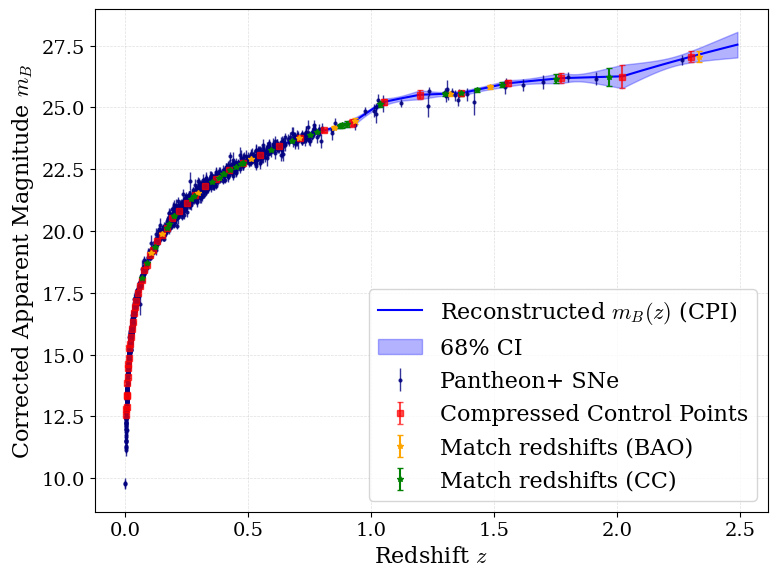

In [28]:
z_plot = np.linspace(0.01, max(z_sn) * 1.1, 1000)
mB_obs_std = np.sqrt(np.diag(cov_full))
import matplotlib.pyplot as plt
n_MC = 1000
mB_rec_samples = np.zeros((n_MC, len(z_plot)))
chain_indices = np.random.choice(len(mB_cp_chain), n_MC, replace=False) # 从链里面抽nMC个序号值 36维度的array
for i, chain_idx in enumerate(chain_indices):
    mB_rec_samples[i] = utils.evaluate_mB(z_plot, mB_cp_chain[chain_idx], z_cp)
mB_mean = np.mean(mB_rec_samples, axis=0)   # (N_z,)
mB_std  = np.std(mB_rec_samples, axis=0)    # (N_z,)

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 14
})

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(z_plot, mB_mean, label=r'Reconstructed $m_B(z)$ (CPI)', color='blue')

# Plot data from different sources
ax.errorbar(z_sn, mB_obs, mB_obs_std, fmt='o', label='Pantheon+ SNe',
            capsize=0, ms=2, elinewidth=1, color='navy', alpha=0.8)

ax.errorbar(z_cp, mB_cp, mB_cp_std, fmt='s', label='Compressed Control Points',
            color='red', alpha=0.7, markersize=4, capsize=2, linestyle='none')

ax.errorbar(z_baomatch, mB_baomatch, mB_baomatch_std, fmt='*', label='Match redshifts (BAO)',
            markersize=4, capsize=2, linestyle='none', color='orange') 

ax.errorbar(z_ccmatch, mB_ccmatch, mB_ccmatch_std, fmt='*', label='Match redshifts (CC)',
            markersize=4, capsize=2, linestyle='none', color='g') 


ax.fill_between(z_plot, mB_mean - mB_std, mB_mean + mB_std, color='blue', alpha=0.3, label=r'68% CI')

ax.set_xlabel(r'Redshift $z$', fontsize=16)
ax.set_ylabel(r'Corrected Apparent Magnitude $m_B$', fontsize=16)

ax.legend(loc='best', frameon=True, fontsize=16)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('fig/mB_reconstruction_CPI_.pdf', bbox_inches='tight')
plt.show()



<ErrorbarContainer object of 3 artists>

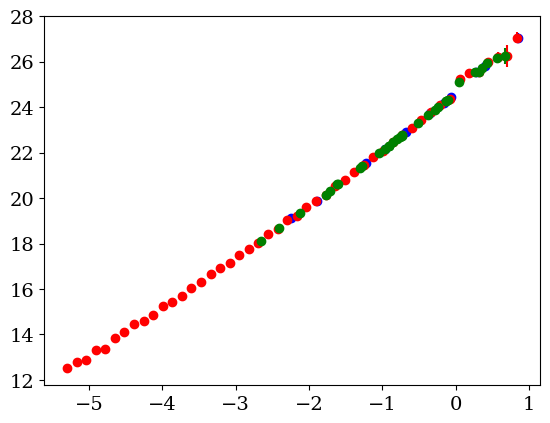

In [29]:
plt.errorbar(np.log(z_baomatch), mB_baomatch, mB_baomatch_std, fmt='o', color='b')
plt.errorbar(np.log(z_cp), mB_cp, mB_cp_std, fmt='o', color='r')
plt.errorbar(np.log(z_ccmatch), mB_ccmatch, mB_ccmatch_std,  fmt='o', color='g')

In [30]:
# # 我们需要保存z_match mB_match mB_match_cov
# mB_cp = np.mean(mB_cp_chain, axis=0)
# mB_cp_std = np.sqrt(np.diag(mB_cp_cov))
# np.savetxt("output/mB_match_summary.txt", np.c_[z_match, mB_match, mB_match_std], header="z_match  mB_match  mB_match_std")
# np.save("output/mB_match_CPI.npy", mB_match)
# np.save("output/mB_match_cov_CPI.npy", mB_match_cov)
np.savetxt("output/mB_cp_summary.txt", np.c_[z_cp, mB_cp, mB_cp_std], header="z_cp  mB_cp  mB_cp_std")
np.save("output/mB_cp_cov.npy", mB_cp_cov)
np.save("output/mB_cp_chain.npy", mB_cp_chain)
# np.save("output/mB_match_chain.npy", mB_baomatch_chain)
# np.save("output/z_cp.npy", z_cp)


Processing prior: Planck2018MB0


/home/zxw/work/CDDR_Test/.venv/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:526: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


chi2: 99.27, p-value: 0.0000
Number of BAO points: 11


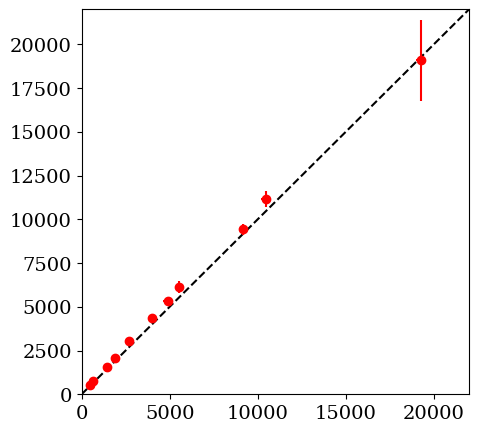

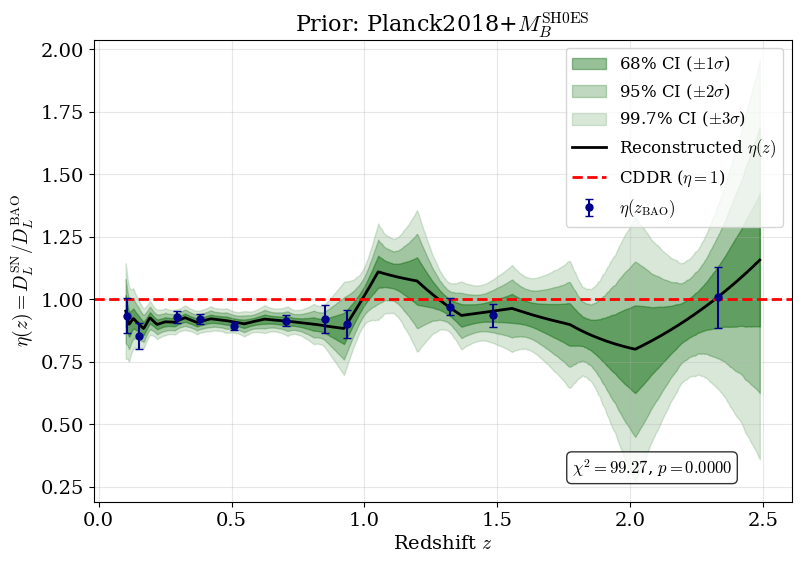

BAO information
BAO point 1: z=0.106, η=0.9342 ± 0.0698
BAO point 2: z=0.150, η=0.8536 ± 0.0506
BAO point 3: z=0.295, η=0.9299 ± 0.0228
BAO point 4: z=0.380, η=0.9234 ± 0.0201
BAO point 5: z=0.510, η=0.8932 ± 0.0166
BAO point 6: z=0.706, η=0.9157 ± 0.0203
BAO point 7: z=0.850, η=0.9216 ± 0.0556
BAO point 8: z=0.934, η=0.9024 ± 0.0556
BAO point 9: z=1.321, η=0.9717 ± 0.0341
BAO point 10: z=1.484, η=0.9367 ± 0.0469
BAO point 11: z=2.330, η=1.0083 ± 0.1219

Processing prior: Planck2018MB23


/home/zxw/work/CDDR_Test/.venv/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:526: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


chi2: 8.82, p-value: 0.6381
Number of BAO points: 11


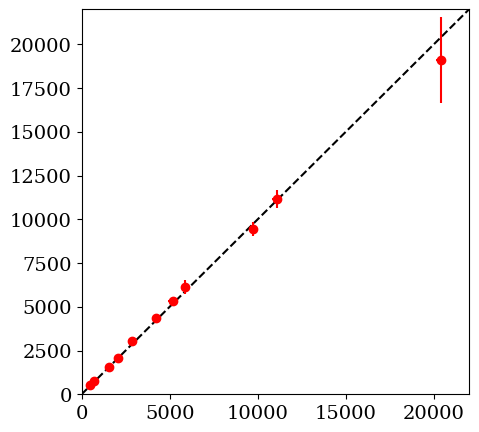

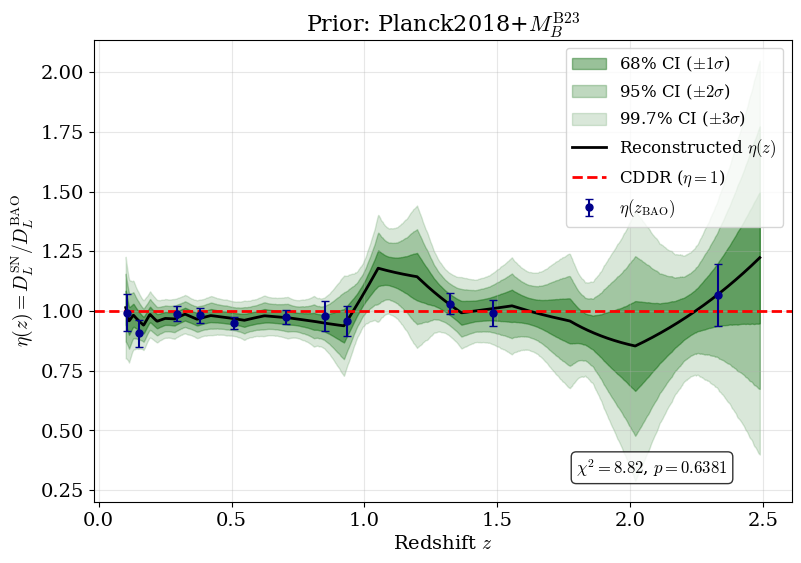

BAO information
BAO point 1: z=0.106, η=0.9935 ± 0.0772
BAO point 2: z=0.150, η=0.9075 ± 0.0568
BAO point 3: z=0.295, η=0.9893 ± 0.0320
BAO point 4: z=0.380, η=0.9821 ± 0.0303
BAO point 5: z=0.510, η=0.9501 ± 0.0261
BAO point 6: z=0.706, η=0.9748 ± 0.0306
BAO point 7: z=0.850, η=0.9781 ± 0.0623
BAO point 8: z=0.934, η=0.9576 ± 0.0642
BAO point 9: z=1.321, η=1.0313 ± 0.0438
BAO point 10: z=1.484, η=0.9927 ± 0.0535
BAO point 11: z=2.330, η=1.0678 ± 0.1296


In [31]:
priors = [
    {"name":"Planck2018MB0", "label":"Planck2018+$M_B^\\mathrm{SH0ES}$", "MB": -19.253, "MB_err": 0.027, "rd": 147.09, "rd_err": 0.26},
    # {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\text{B23}$", "MB": -19.396, "MB_err": 0.0404, "rd": 147.09, "rd_err": 0.26},
    {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\mathrm{B23}$", "MB": -19.384, "MB_err": 0.052, "rd": 147.09, "rd_err": 0.26},
]
z_plot = np.linspace(0.01, max(z_sn) * 1.1, 1000)
n_MC = 1000

# ---------- 主循环（对每个先验） ----------
for prior in priors:
    MB = prior["MB"]; MB_err = prior["MB_err"]
    rd = prior["rd"]; rd_err = prior["rd_err"]
    print(f"\nProcessing prior: {prior['name']}")

    # BAO: 把两种BAO数据转化为 DL
    DL_bao_DV, DL_bao_DV_err = bao_DV_to_DL(z_bao_dv, DV_rd, DV_rd_err, H_dv, H_dv_err, rd, rd_err)
    DL_bao_DM, DL_bao_DM_err = bao_DM_to_DL(z_bao_dm, DM_rd, DM_rd_err, rd, rd_err)

    # 合并 BAO 点（保存原始观测数据）
    DL_bao_obs = np.concatenate((DL_bao_DV, DL_bao_DM))        # BAO观测距离
    DL_bao_obs_err = np.concatenate((DL_bao_DV_err, DL_bao_DM_err)) # BAO观测误差

    # GP拟合BAO数据
    gp_bao = fit_gp_DL(z_baomatch, DL_bao_obs, DL_bao_obs_err)
    DL_bao_gp_mean, DL_bao_gp_std = gp_bao.predict(z_plot.reshape(-1,1), return_std=True)

    # 从GP中抽取BAO距离样本
    DL_bao_samples = gp_bao.sample_y(z_plot.reshape(-1,1), n_MC).T # 从高斯过程中每个z_plot处抽取n_MC个样本

    # 超新星抽样
    chain_indices = np.random.choice(len(mB_cp_chain), n_MC, replace=False) # 从链里面抽nMC个序号值 36维度的array
    MB_samples = np.random.normal(MB, MB_err, n_MC) # 在高斯分布中抽取nMC个MB点

    # 计算SN距离（在整个红移网格上）
    DL_sn_samples = np.zeros((n_MC, len(z_plot)))
    for i, chain_idx in enumerate(chain_indices):
        DL_sn_samples[i] = compute_DL_SN(z_plot, mB_cp_chain[chain_idx], MB_samples[i], z_cp) # 这里的的函数用控制点差值计算出了DL
    
    DL_sn_mean = np.mean(DL_sn_samples, axis=0)
    DL_sn_err = 0.5 * (np.percentile(DL_sn_samples, 84, axis=0) - np.percentile(DL_sn_samples, 16, axis=0))

    # 计算SN距离（在BAO观测红移点上）→ 用于画BAO点的误差棒
    DL_sn_at_bao = np.zeros((n_MC, len(z_baomatch)))
    for i, chain_idx in enumerate(chain_indices):
        DL_sn_at_bao[i] = compute_DL_SN(z_baomatch, mB_cp_chain[chain_idx], MB_samples[i], z_cp)
    
    DL_sn_mean_at_bao = np.mean(DL_sn_at_bao, axis=0)   # 在BAO红移处的SN距离中值
    DL_sn_err_at_bao = 0.5 * (np.percentile(DL_sn_at_bao, 84, axis=0) - np.percentile(DL_sn_at_bao, 16, axis=0))
    
    # 计算η(z) = SN距离 / BAO距离
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_err = 0.5 * (np.percentile(eta_samples, 84, axis=0) - np.percentile(eta_samples, 16, axis=0))

    # 计算BAO观测点处的η值（用于误差棒）
    eta_match = DL_sn_mean_at_bao / DL_bao_obs
    eta_match_std = np.abs(eta_match) * np.sqrt(
        (DL_sn_err_at_bao / DL_sn_mean_at_bao)**2 + (DL_bao_obs_err / DL_bao_obs)**2
    )

    # 计算chi2
    chi2_val, p_val = eta_chi2(eta_match, eta_match_std)
    print(f"chi2: {chi2_val:.2f}, p-value: {p_val:.4f}")
    print(f"Number of BAO points: {len(z_baomatch)}")

    plt.figure(figsize=(5,5))
    plt.axline((0, 0), slope=1, linestyle='--', color='k')
    plt.errorbar(DL_sn_mean_at_bao, DL_bao_obs, DL_sn_err_at_bao, DL_bao_obs_err,fmt='o',color='red')
    plt.xlim(0, 22000)
    plt.ylim(0, 22000)
    plt.show()

    # 绘图
    plt.figure(figsize=(9,6))
    mask = z_plot > 0.1
    
    for sigma, alpha_fill, label_fill in zip([1, 2, 3], [0.4, 0.25, 0.15],[r'68% CI ($\pm 1\sigma$)', r'95% CI ($\pm 2\sigma$)', r'99.7% CI ($\pm 3\sigma$)']):
            plt.fill_between(z_plot[mask],
                    (eta_mean - sigma * eta_err)[mask],
                    (eta_mean + sigma * eta_err)[mask],
                    color='darkgreen', alpha=alpha_fill, label=label_fill)
    # 1. η(z)重建曲线
    plt.plot(z_plot[mask], eta_mean[mask], color='black', label=r'Reconstructed $\eta(z)$', linewidth=2)
    # plt.fill_between(z_plot[mask], eta_mean[mask] - eta_err[mask], eta_mean[mask] + eta_err[mask], color='red', alpha=0.3, label=r'1$\sigma$ uncertainty')
    
    # 2. η=1参考线
    plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label=r'CDDR ($\eta=1$)')
    
    # 3. BAO观测点（这才是你要画的点！）
    # plt.errorbar(z_match, eta_match, yerr=eta_match_std, fmt='o', color='darkblue', capsize=3, markersize=8, label=r'$\eta(z_{\mathrm{BAO}})$', zorder=5)
    plt.errorbar(z_baomatch, eta_match, yerr=eta_match_std, fmt='o', label=r'$\eta(z_\mathrm{BAO})$', color='darkblue', capsize=3, markersize=5)
    
    # 4. 坐标轴和标题
    plt.xlabel('Redshift $z$', fontsize=14)
    plt.ylabel(r'$\eta(z) = D_L^{\mathrm{SN}} / D_L^{\mathrm{BAO}}$', fontsize=14)
    plt.title(f"Prior: {prior['label']}", fontsize=16)
    
    # 5. 统计信息
    textstr = f'$\\chi^2 = {chi2_val:.2f}$, $p = {p_val:.4f}$'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.8, 0.05, textstr, transform=plt.gca().transAxes, ha='center', va='bottom', fontsize=12, bbox=props)
    
    plt.legend(fontsize=12, loc='best')
    plt.grid(alpha=0.3)
    plt.savefig(rf"fig/eta_CPI_reconstruct_{prior['name']}.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印BAO点信息
    print("BAO information")
    for i, (z, eta, eta_err) in enumerate(zip(z_baomatch, eta_match, eta_match_std)):
        print(rf"BAO point {i+1}: z={z:.3f}, η={eta:.4f} ± {eta_err:.4f}")